[[0.50961536 0.52403843 0.53365386 ... 0.99038464 0.97596157 0.94711536]
 [0.52403843 0.5480769  0.55288464 ... 1.         0.9951923  0.99038464]
 [0.52884614 0.55288464 0.5625     ... 0.99038464 0.9951923  0.99038464]
 ...
 [0.0625     0.07692308 0.08173077 ... 0.23076923 0.21634616 0.17788461]
 [0.05288462 0.0625     0.0673077  ... 0.1875     0.17788461 0.15384616]
 [0.05288462 0.05769231 0.0625     ... 0.15384616 0.14423077 0.125     ]]
[[0.52073735 0.51152074 0.51152074 ... 0.9769585  0.9861751  0.9861751 ]
 [0.52073735 0.52073735 0.52073735 ... 0.9769585  0.9861751  0.9861751 ]
 [0.52073735 0.5253456  0.5253456  ... 0.9769585  0.98156685 0.9861751 ]
 ...
 [0.05990783 0.05990783 0.05990783 ... 0.19354838 0.19354838 0.19815668]
 [0.05990783 0.05990783 0.05990783 ... 0.17511521 0.1889401  0.1889401 ]
 [0.05529954 0.05529954 0.05529954 ... 0.09677419 0.15668203 0.1843318 ]]
Root Mean Squared Error (RMSE): 0.07181375473737717


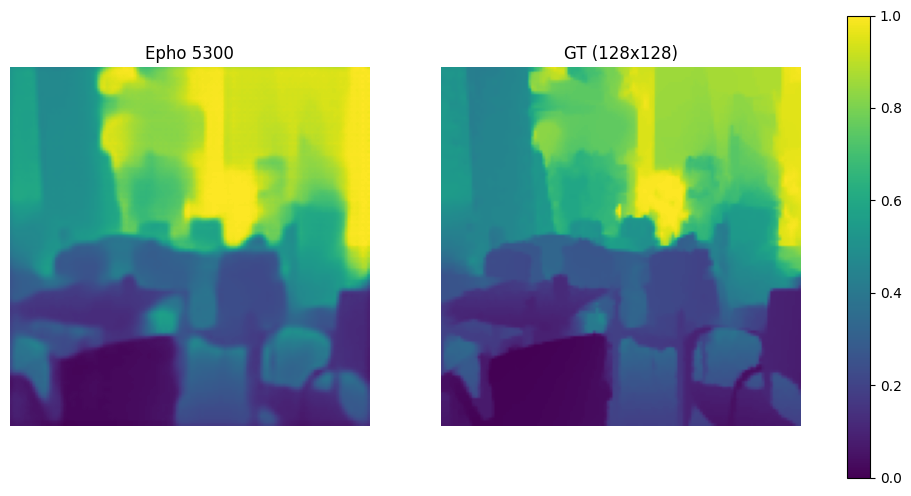

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_and_normalize_depth_map(filename, resize_to=None):
    # 读取三通道深度图
    depth_map = cv2.imread(filename)
    
    if depth_map is None:
        print(f"Failed to load depth map: {filename}")
        return None

    # 调整深度图大小（如果需要）
    if resize_to is not None:
        depth_map = cv2.resize(depth_map, resize_to, interpolation=cv2.INTER_AREA)

    # 提取单通道深度信息（假设深度信息在第一个通道）
    single_channel_depth_map = depth_map[:, :, 0]
    min_val, max_val =(0.0, 1.0)
    single_channel_depth_map = single_channel_depth_map.astype(np.float32)
    single_channel_depth_map = (single_channel_depth_map - single_channel_depth_map.min()) / (single_channel_depth_map.max() - single_channel_depth_map.min() + 1e-8)
    single_channel_depth_map = single_channel_depth_map * (max_val - min_val) + min_val
    # print(single_channel_depth_map)
    # 正常化深度图以便于显示
    # depth_map_normalized = cv2.normalize(single_channel_depth_map, None, 0, 255, cv2.NORM_MINMAX)
    # depth_map_normalized = np.uint8(depth_map_normalized)
    print(single_channel_depth_map)

    return single_channel_depth_map

def calculate_rmse(image1, image2):
    # 确保两张图像尺寸相同
    if image1.shape != image2.shape:
        raise ValueError("The dimensions of the two images do not match.")
    
    # 计算均方根误差
    mse = np.mean(abs((image1 - image2)) ** 2)

    rmse = np.sqrt(mse)
    return rmse

# 读取并处理两张深度图
depth_map1 = read_and_normalize_depth_map(r'C:\Users\10528\Desktop\FocusDiff\generate_imgs\MFFW\20240628_125256\epoch_5350\png_imgs\MFFW_48.png')
depth_map2 = read_and_normalize_depth_map(r'C:\Users\10528\Desktop\FocusDiff\data\NYUv2\train_depth\00117_depth.png',resize_to=(128, 128))

# 将第一张深度图也调整为128x128以计算RMSE
depth_map1_resized = cv2.resize(depth_map1, (128, 128), interpolation=cv2.INTER_AREA)

# 计算均方根误差
if depth_map1_resized is not None and depth_map2 is not None:
    rmse = calculate_rmse(depth_map1, depth_map2)
    print(f"Root Mean Squared Error (RMSE): {rmse}")

# 创建子图
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# 显示第一张深度图
if depth_map1 is not None:
    axs[0].imshow(depth_map1)
    axs[0].set_title('Epho 5300')
    axs[0].axis('off')
    
# 显示第二张深度图
if depth_map2 is not None:
    axs[1].imshow(depth_map2)
    axs[1].set_title('GT (128x128)')
    axs[1].axis('off')

# 显示颜色条
fig.colorbar(axs[0].images[0], ax=axs, orientation='vertical', fraction=.1)

plt.show()

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
def read_and_normalize_depth_map(filename, resize_to=None):
    # 读取三通道深度图
    depth_map = cv2.imread(filename)
    
    if depth_map is None:
        print(f"Failed to load depth map: {filename}")
        return None

    # 调整深度图大小（如果需要）
    if resize_to is not None:
        depth_map = cv2.resize(depth_map, resize_to, interpolation=cv2.INTER_AREA)

    # 提取单通道深度信息（假设深度信息在第一个通道）
    single_channel_depth_map = depth_map[:, :, 0]
    min_val, max_val =(0.0, 1.0)
    single_channel_depth_map = single_channel_depth_map.astype(np.float32)
    single_channel_depth_map = (single_channel_depth_map - single_channel_depth_map.min()) / (single_channel_depth_map.max() - single_channel_depth_map.min() + 1e-8)
    single_channel_depth_map = single_channel_depth_map * (max_val - min_val) + min_val
    # 正常化深度图以便于显示
    # depth_map_normalized = np.uint8(single_channel_depth_map)
    return single_channel_depth_map

def calculate_rmse(image1, image2):
    # 确保两张图像尺寸相同
    if image1.shape != image2.shape:
        raise ValueError("The dimensions of the two images do not match.")
    
    # 计算均方根误差
    mse = np.mean(((image1 - image2)) ** 2)
    rmse = np.sqrt(mse)
    return rmse

def calculate_total_rmse_by_order(folder1, folder2, resize_to=(128, 128)):
    total_rmse = 0
    count = 0

    files1 = sorted([os.path.join(folder1, f) for f in os.listdir(folder1) if os.path.isfile(os.path.join(folder1, f))])
    files2 = sorted([os.path.join(folder2, f) for f in os.listdir(folder2) if os.path.isfile(os.path.join(folder2, f))])

    # 确保两个文件夹中的文件数量相同
    min_length = min(len(files1), len(files2))

    for i in range(min_length):
        file1 = files1[i]
        file2 = files2[i]

        depth_map1 = read_and_normalize_depth_map(file1)
        depth_map2 = read_and_normalize_depth_map(file2, resize_to)

        if depth_map1 is not None and depth_map2 is not None:
            rmse = calculate_rmse(depth_map1, depth_map2)
            total_rmse += rmse
            count += 1

    if count > 0:
        average_rmse = total_rmse / count
    else:
        average_rmse = None

    return average_rmse

# 文件夹路径
folder1 = r'C:\Users\10528\Desktop\FusionDiff\generate_imgs\MFFW\20240628_125256\epoch_5350\png_imgs'
folder2 = r'C:\Users\10528\Desktop\FusionDiff\data\NYUv2\train_depth'

average_rmse = calculate_total_rmse_by_order(folder1, folder2, resize_to=(128, 128))

if average_rmse is not None:
    print(f"Average RMSE: {average_rmse}")
else:
    print("No matching image pairs found.")


Failed to load depth map: C:\Users\10528\Desktop\FusionDiff\generate_imgs\MFFW\20240628_125256\epoch_5350\png_imgs\valid_log.txt
Average RMSE: 0.32733505501489807


In [12]:
import torch

# 假设这两个张量
tensor1 = torch.randn(2, 3, 2, 2)  # (2, 3, 128, 128)
tensor2 = torch.randn(2, 2, 3, 2, 2)  # (2, 5, 3, 128, 128)
print(tensor1)
print(tensor2)
# 扩展 tensor1 的形状到 (2, 1, 3, 128, 128)
tensor1_expanded = tensor1.unsqueeze(1).expand_as(tensor2)
print(tensor1_expanded)
# 在第1维（不同焦距图像数量）进行拼接
result = torch.cat(( tensor1_expanded,tensor2,), dim=2)
print(result)
print(result.shape)  # 输出形状 (2, 6, 3, 128, 128)


tensor([[[[ 1.4006,  0.3523],
          [ 0.7258,  0.8577]],

         [[-1.0003, -0.9323],
          [-0.6653,  0.3358]],

         [[-0.1115, -0.3825],
          [ 0.6405, -2.5784]]],


        [[[-0.2309, -1.6842],
          [-1.1279,  0.3553]],

         [[-0.5193,  0.4317],
          [-0.5838,  0.8503]],

         [[ 0.1835,  1.3848],
          [-1.5913, -0.3455]]]])
tensor([[[[[ 0.5389,  0.1215],
           [ 0.6413,  1.2552]],

          [[-0.3625,  0.3613],
           [ 0.8757,  0.4210]],

          [[ 0.3203, -1.6726],
           [-0.4065, -1.0185]]],


         [[[ 0.3876,  0.3763],
           [ 0.0471, -0.1627]],

          [[ 0.5129, -0.8288],
           [ 1.5377, -0.8845]],

          [[-1.5355,  0.2010],
           [ 1.0122,  0.4377]]]],



        [[[[-1.0223, -1.3080],
           [-0.1820,  1.1780]],

          [[ 0.4853,  0.0288],
           [-0.4693, -0.4746]],

          [[-0.1443,  0.1503],
           [-0.0597,  0.3218]]],


         [[[ 0.0875, -0.4119],
          

: 

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Sat Aug 17 18:46:20 2019

@author: 不用先生
"""

import cv2
import numpy as np

input_fn='03.jpg'

def my_guidedFilter_oneChannel(srcImg,guidedImg,rad=9,eps=0.01):
    
    srcImg=srcImg/255.0
    guidedImg=guidedImg/255.0
    img_shape=np.shape(srcImg)
    
#    dstImg=np.zeros(img_shape,dtype=float)
#    
#    P_mean=np.zeros(img_shape,dtype=float)
#    I_mean=np.zeros(img_shape,dtype=float)
#    I_square_mean=np.zeros(img_shape,dtype=float)
#    I_mul_P_mean=np.zeros(img_shape,dtype=float)
#    var_I=np.zeros(img_shape,dtype=float)
#    cov_I_P=np.zeros(img_shape,dtype=float)
#    
#    a=np.zeros(img_shape,dtype=float)
#    b=np.zeros(img_shape,dtype=float)
#    a_mean=np.zeros(img_shape,dtype=float)
#    b_mean=np.zeros(img_shape,dtype=float)
    
    P_mean=cv2.boxFilter(srcImg, -1, (rad, rad), normalize=True) 
    I_mean=cv2.boxFilter(guidedImg,-1, (rad, rad), normalize=True) 
    
    I_square_mean=cv2.boxFilter(np.multiply(guidedImg,guidedImg), -1, (rad, rad), normalize=True) 
    I_mul_P_mean=cv2.boxFilter(np.multiply(srcImg,guidedImg), -1, (rad, rad), normalize=True)
    
    var_I=I_square_mean-np.multiply(I_mean,I_mean)
    cov_I_P=I_mul_P_mean-np.multiply(I_mean,P_mean)
    
    a=cov_I_P/(var_I+eps)
    b=P_mean-np.multiply(a,I_mean)
    
    a_mean=cv2.boxFilter(a, -1, (rad, rad), normalize=True) 
    b_mean=cv2.boxFilter(b, -1, (rad, rad), normalize=True) 
    
    dstImg=np.multiply(a_mean,guidedImg)+b_mean
    
    return dstImg*255.0
    

def my_guidedFilter_threeChannel(srcImg,guidedImg,rad=9,eps=0.01):
    
    img_shape=np.shape(srcImg)

    dstImg=np.zeros(img_shape,dtype=float)

    for ind in range(0,img_shape[2]):
        dstImg[:,:,ind]=my_guidedFilter_oneChannel(srcImg[:,:,ind],
              guidedImg[:,:,ind],rad,eps)
    
    dstImg=dstImg.astype(np.uint8)
    
    return dstImg


def main():
    img=cv2.imread(input_fn)
    print(np.shape(img))

    dstimg=my_guidedFilter_threeChannel(img,img,9,0.01)
    print(np.shape(dstimg))
#    cv2.imwrite('output.jpg',dstimg)
    cv2.imshow('output',dstimg)
    cv2.waitKey(0)
    
if __name__ == '__main__':
    main()


Noise Mean: 0.021774277091026306
Noise Std: 0.27388158440589905


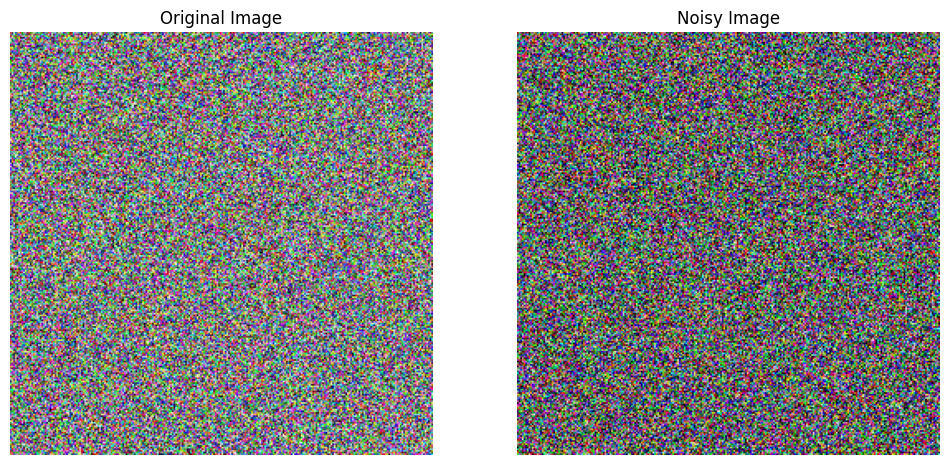

In [5]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0.0, std=0.1):
    """
    向图像添加高斯噪声

    Args:
        image (torch.Tensor): 输入图像，形状为 (C, H, W)
        mean (float): 高斯噪声的均值
        std (float): 高斯噪声的标准差

    Returns:
        torch.Tensor: 添加高斯噪声后的图像
    """
    noise = torch.randn(image.size()) * std + mean
    noisy_image = image + noise
    noisy_image = torch.clamp(noisy_image, 0, 2)  # 将图像像素值限制在 [0, 1] 范围内
    return noisy_image, noise

def compute_noise_content(original_image, noisy_image):
    """
    计算图像中的噪声含量

    Args:
        original_image (torch.Tensor): 原始图像，形状为 (C, H, W)
        noisy_image (torch.Tensor): 添加噪声后的图像，形状为 (C, H, W)

    Returns:
        float: 噪声的均值
        float: 噪声的标准差
    """
    noise = noisy_image - original_image
    noise_mean = torch.mean(noise)
    noise_std = torch.std(noise)
    return noise_mean.item(), noise_std.item()

# 创建一个示例图像（例如：从0到1的随机图像）
image = torch.rand(3, 256, 256)  # 假设图像大小为 256x256，3个通道（RGB）

# 添加高斯噪声
noisy_image, noise = add_gaussian_noise(image, mean=0.0, std=0.3)

# 计算噪声含量
noise_mean, noise_std = compute_noise_content(image, noisy_image)

print(f"Noise Mean: {noise_mean}")
print(f"Noise Std: {noise_std}")

# 转换图像格式以便使用matplotlib显示
to_pil = transforms.ToPILImage()

original_image_pil = to_pil(image)
noisy_image_pil = to_pil(noisy_image)

# 显示原始图像和添加噪声后的图像
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(original_image_pil)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(noisy_image_pil)
ax[1].set_title('Noisy Image')
ax[1].axis('off')

plt.show()


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
cost=torch.rand(3, 256, 256)
print(F.softmax(cost,1).size()) 

torch.Size([3, 256, 256])


In [11]:
class SKConv(nn.Module):
    def __init__(self, features, M=2, G=32, r=16, stride=1, L=32):
        """ Constructor
        Args:
            features: input channel dimensionality.
            M: the number of branchs.
            G: num of convolution groups.
            r: the ratio for compute d, the length of z.
            stride: stride, default 1.
            L: the minimum dim of the vector z in paper, default 32.
        """
        super(SKConv, self).__init__()
        d = max(int(features/r), L)
        self.M = M
        self.features = features
        self.convs = nn.ModuleList([])
        for i in range(M):
            self.convs.append(nn.Sequential(
                nn.Conv2d(features, features, kernel_size=3, stride=stride, padding=1, groups=G, bias=False),
                nn.BatchNorm2d(features),
                nn.ReLU(inplace=False)
            ))
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Sequential(nn.Conv2d(features, d, kernel_size=1, stride=1, bias=False),
                                nn.BatchNorm2d(d),
                                nn.ReLU(inplace=False))
        self.fcs = nn.ModuleList([])
        for i in range(M):
            self.fcs.append(
                 nn.Conv2d(d, features, kernel_size=1, stride=1)
            )
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x,y):
        
        batch_size = x.shape[0]
        
        feats = [conv(x) for conv in self.convs]      
        feats = torch.cat(feats, dim=1)
        feats = feats.view(batch_size, self.M, self.features, feats.shape[2], feats.shape[3])
        
        feats_U = torch.sum(feats, dim=1)
        feats_S = self.gap(feats_U)
        feats_Z = self.fc(feats_S)
 
        attention_vectors = [fc(feats_Z) for fc in self.fcs]
        attention_vectors = torch.cat(attention_vectors, dim=1)
        attention_vectors = attention_vectors.view(batch_size, self.M, self.features, 1, 1)
        attention_vectors = self.softmax(attention_vectors)
        
        feats_V = torch.sum(feats*attention_vectors, dim=1)
        
        return feats_V
net=SKConv(32,M=2, G=32, r=16, stride=1, L=32)
print(net(torch.randn(2,32,255,255)))

tensor([[[[0.0000e+00, 0.0000e+00, 2.3979e-01,  ..., 0.0000e+00,
           0.0000e+00, 3.7224e-01],
          [0.0000e+00, 2.5948e-01, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 7.8029e-01, 0.0000e+00,  ..., 3.4074e-01,
           3.9382e-01, 3.4559e-01],
          ...,
          [0.0000e+00, 1.4719e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 3.6095e-01],
          [0.0000e+00, 1.2314e+00, 3.2360e-01,  ..., 0.0000e+00,
           0.0000e+00, 2.0595e-01],
          [7.3388e-03, 5.9647e-01, 1.5764e-01,  ..., 0.0000e+00,
           3.7733e-01, 0.0000e+00]],

         [[0.0000e+00, 0.0000e+00, 3.2792e-01,  ..., 3.6861e-01,
           7.7888e-01, 1.0837e+00],
          [1.1794e-02, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           1.2440e-01, 9.1180e-01],
          [6.1991e-01, 1.3881e+00, 5.9362e-01,  ..., 0.0000e+00,
           4.1919e-01, 7.9927e-01],
          ...,
          [2.2419e-01, 2.0004e-01, 3.4538e-02,  ..., 6.3265